# Function 1: 2D Radiation Detection

Explore the initial 10 (x, y) points, visualize the landscape, and suggest the next input to submit.

- 2D, sparse signal (only proximity yields non-zero reading).
- One hotspot; goal is to find it with limited queries.

## 1. Setup and load data

In [1]:
# ==== External libraries ====
import sys
import copy
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.stats import norm
import matplotlib.pyplot as plt

# ==== Project path + internal utilities ====
repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from src.utils.load_challenge_data import (
    load_function_data,
    load_problem_data_csv,
    assert_not_under_initial_data,
)
from src.utils.sampling_utils import sample_candidates
from src.utils.warping import apply_output_warping
from src.utils.plot_utilities import prepare_surface_for_plot as _prepare_surface_for_plot

np.random.seed(42)


In [2]:
# Load: under data/ we use only CSV. observations.csv if present, else initial_data (read-only).
local_dir = repo_root / "data" / "problems" / "function_1"
csv_path = local_dir / "observations.csv"
PLOT_EXPORT_DIR = repo_root / "data" / "results" 
print('Set data directory to', local_dir)

# Run-time flags — toggle without re-running the whole notebook
IF_SHOW_PLOT      = True   # call plt.show() after each figure
IF_EXPORT_PLOT    = False  # save figures to PLOT_EXPORT_DIR
IF_EXPORT_QUERIES = True   # write next_x to data/submissions/
IF_APPEND_DATA    = False  # append new observation to observations.csv

print('Control flags set')


Set data directory to /Users/nikolaskarefyllidis/Desktop/60_ML-AI/10 main optimization/10 ICL BBO Challenge/black-box-optimization/data/problems/function_1
Control flags set


In [3]:
############################################
# SELECT OPTIMIZATION ALGORITHM SOLUTION EXPORT #
############################################
# Which solver's suggestion to save to data/submissions/function_1/.
# Options: 'MyBO' | 'Optuna-TPE' | 'Optuna-GP' | 'TuRBO' | 'GA'
NEXT_QUERY_SOLUTION = 'MyBO'

print(50*'=')
print(f'NEXT_QUERY_SOLUTION = {NEXT_QUERY_SOLUTION}')
print(50*'=')

NEXT_QUERY_SOLUTION = MyBO


In [4]:
############################################
# Probabilistic surrogate models (sklearn) #
############################################

# ==== GaussianProcessRegressor: fits GP to (X, y); predict() returns posterior μ and σ. ====

from sklearn.gaussian_process import GaussianProcessRegressor
# Kernels define the GP covariance (smoothness / structure of the objective):
#   RBF              — infinitely smooth, isotropic.
#   Matern           — rougher than RBF; ν=1.5 → once differentiable.
#   ConstantKernel   — output-scale prefactor.
#   WhiteKernel      — explicit i.i.d. observation noise.
#   DotProduct       — linear (inner-product) kernel.
#   RationalQuadratic — scale mixture of RBFs; multi-length-scale.
#   ExpSineSquared   — periodic / cyclic patterns.
#   PairwiseKernel   — wraps any sklearn pairwise metric as a kernel.
from sklearn.gaussian_process.kernels import (RBF, Matern, ConstantKernel, WhiteKernel)

# ==== Acquisition functions (skopt) ====

from skopt.acquisition import (gaussian_ei, gaussian_pi, gaussian_lcb)
# skopt assumes minimization — we fit aux GPs on −y so argmax acq ≡ argmax y.
#   gaussian_ei  — E[max(f(x)−f(x⁺), 0)]; ξ trades off exploitation vs exploration.
#   gaussian_pi  — P(f(x) > f(x⁺)+ξ); greedier than EI.
#   gaussian_lcb — μ(x) − κσ(x); minimize LCB of −y ≡ maximize UCB of y.

# ==== Candidate samplers (skopt) ====

from skopt.sampler import (Lhs, Sobol)
# Generate the pool of points over which the acquisition function is maximized.
#   Lhs   — Latin Hypercube: stratified, good uniform coverage.
#   Sobol — quasi-random low-discrepancy sequence; better than random for d ≥ 2.



In [5]:
# ==== All inputs in-script (no YAML). You can switch to config later. ====

# ==== GP kernel hyperparameters ====
CONSTANT_KERNEL_SCALE = 1.0    # output-scale; normalized y so value matters little
LENGTH_SCALE          = 0.20   # init length-scale; sklearn optimizes this — lower = wigglier
GP_ALPHA              = 1e-6   # nugget for numerical stability; raise to 1e-4 if Cholesky fails
MATERN_NU             = 1.5    # roughness: 0.5=exp, 1.5=C¹, 2.5=C², ∞=RBF
WHITE_NOISE_LEVEL     = 1e-6   # noise init; raise to 0.01-0.1 if oracle is stochastic

GP_KERNEL             = None   # None / "none" → LML auto-select; "RBF" | "Matern" | "RBF + WhiteKernel" → force that kernel
OPTIMIZE_KERNEL       = True    # fit kernel hyperparameters via LML
N_RESTARTS_KERNEL     = 25     # restarts for LML landscape
CONSTANT_SCALE_BOUNDS = (0.1, 10)     # reasonable output-scale range
LENGTH_SCALE_BOUNDS   = (0.01, 10)    # prevents length-scale collapsing to 0 or running away
WHITE_NOISE_BOUNDS    = (1e-5, 1.0)   # bounded noise; unconstrained upper causes instability

# ==== Output warping (HEBO-style): "none" | "boxcox" | "log" ====
OUTPUT_WARPING = "none"

# ==== Acquisition coefficients ====
# Early (few obs): explore → high ξ/κ.  Late (many obs): exploit → low ξ/κ.
XI_EI_PI  = 0.05   # ξ for EI/PI: 0.25 = explore, 0.05 = exploit near best
KAPPA_UCB = 1.5    # κ for UCB:   3-5  = explore, 1-2  = exploit near mean peak

# ==== Candidate sampling and grid ====
n_cand         = 40000
n_grid         = 200   # 2D grid resolution for plotting
CANDIDATE_SAMPLING_METHOD = "sobol"  # 'grid' | 'lhs' | 'sobol' | 'random'

# ==== Next-query strategy ====
USE_ENSEMBLE    = False   # if True: centroid of EI/PI/UCB when they disagree
SOLO_STRATEGY   = "EI"     # when USE_ENSEMBLE=False: "EI" | "PI" | "UCB"
AGREE_THRESHOLD = 0.15    # max pairwise distance below which we say "agree" and use EI
# F1 is a sparse hotspot: we need to refine NEAR the best point, so a large
# exclusion radius prevents useful exploitation. 0.01 allows refinement while
# still avoiding exact re-querying of existing points.
MIN_DIST_THRESHOLD = 0.01 # minimum L2 distance from any obs; below this use high-dist fallback
BOUNDARY_MARGIN = 0.05    # margin inside [0,1] for candidate sampling

In [6]:
# Prefer local CSV (updated each week); fall back to read-only initial data
if csv_path.exists():
    X, y = load_problem_data_csv(csv_path)
else:
    X, y = load_function_data(function_id=1)
best_idx = np.argmax(y)
best_y, best_x_so_far = y[best_idx], X[best_idx]
print(f"Loaded: X{X.shape}, y{y.shape}. Best: y={best_y:.4g} at x=({best_x_so_far[0]:.4f}, {best_x_so_far[1]:.4f}), n={len(y)}.")
print(f'Project week: {len(y)-10} out of 13')

Loaded: X(17, 2), y(17,). Best: y=0.2371 at x=(0.4430, 0.4110), n=17.
Project week: 7 out of 13


### Optional: output warping (HEBO-inspired)

If `OUTPUT_WARPING` is set to `"boxcox"` or `"log"`, we transform `y` before fitting the GP so the surrogate sees a better-behaved response. Acquisition and `next_x` are computed in warped space (same domain; only the scale of `y` changes). To compare: run once with `OUTPUT_WARPING = None` and once with `OUTPUT_WARPING = "boxcox"` (or `"log"`) and compare the suggested `next_x`; document in project_log.

In [7]:
# Optional output warping (HEBO-inspired): fit GP on transformed y; acquisition in warped space (src.utils.warping)
y_orig = np.asarray(y, dtype=np.float64).copy()
y, warp_params, _msg = apply_output_warping(y_orig, mode=OUTPUT_WARPING)
print(_msg)
WARP_LABEL = (warp_params[0] if warp_params else "None")  # for titles: "log" | "boxcox" | "None"
best_idx = np.argmax(y)
best_y, best_x_so_far = y[best_idx], X[best_idx]

Output warping: None. GP fits raw y. No transform applied.


### Progress
Left: y per query. Right: best y so far (cumulative max).

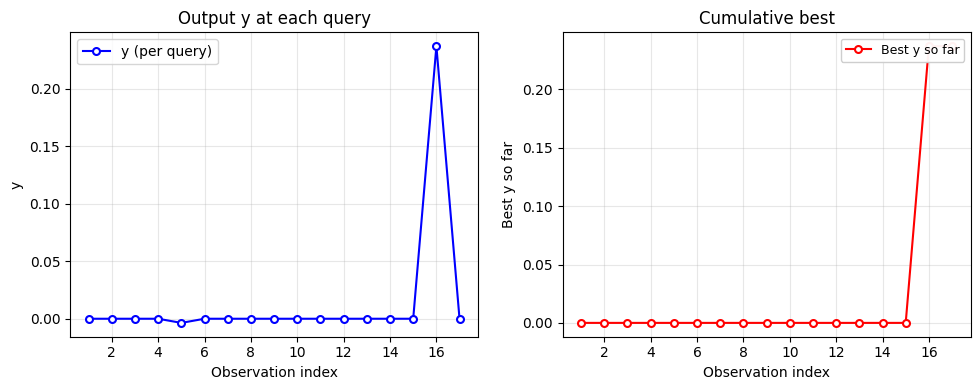

In [8]:
# Convergence: y per query (left) and running best (right)
n_obs = len(y)
obs_idx = np.arange(1, n_obs + 1, dtype=float)
best_so_far = np.maximum.accumulate(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(obs_idx, y, 'o-', color='blue', markersize=5, markerfacecolor='w', markeredgecolor='b', markeredgewidth=1.5, label='y (per query)')
ax1.set_xlabel('Observation index')
ax1.set_ylabel('y')
ax1.set_title('Output y at each query')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(obs_idx, best_so_far, 'o-', color='red', markersize=5, markerfacecolor='w', markeredgecolor='r', markeredgewidth=1.5, label='Best y so far')
ax2.set_xlabel('Observation index')
ax2.set_ylabel('Best y so far')
ax2.set_title('Cumulative best')
ax2.legend(fontsize=9, loc="upper right", framealpha=0.95)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
if IF_SHOW_PLOT:
    plt.show()


## 2. Visualize the points

`X` shape (n, 2): x_1 = `X[:, 0]`, x_2 = `X[:, 1]`. 2D: horizontal = x_1, vertical = x_2; 3D: floor = (x_1, x_2), height = y.

**Two-panel plot:** Left = observations scatter coloured by y (magma); the colour scale is built from the **observation** y range so points span the colormap; grey edges for visibility. Right = IDW-interpolated y contour with observation markers (red) and point labels. SymLog scale is used when output warping is applied.

/Users/nikolaskarefyllidis/Desktop/60_ML-AI/10 main optimization/10 ICL BBO Challenge/black-box-optimization/src/utils/sampling_utils.py:63: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  x = sampler.random(n=n_sobol)[:n]


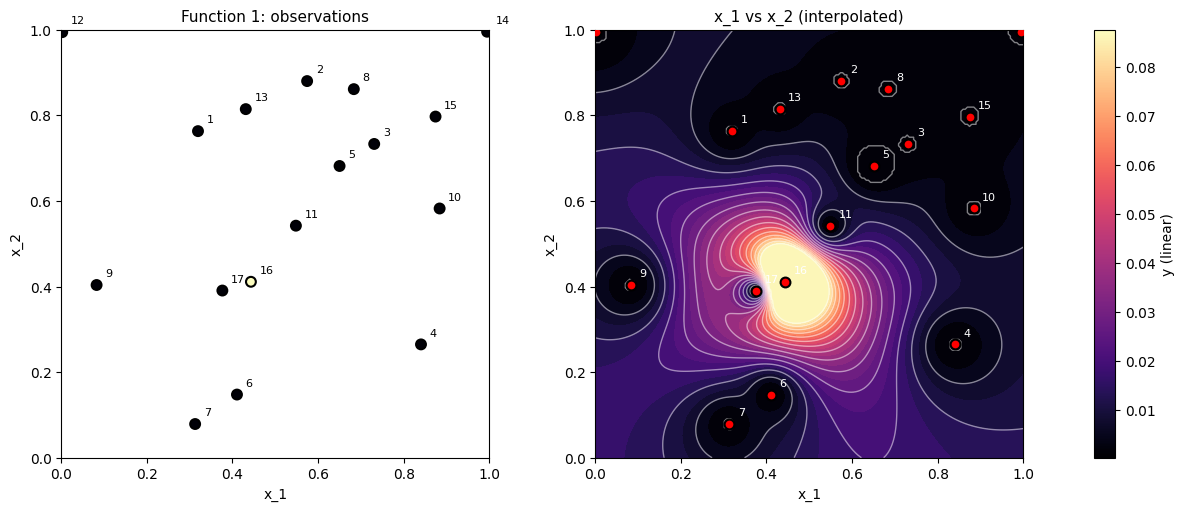

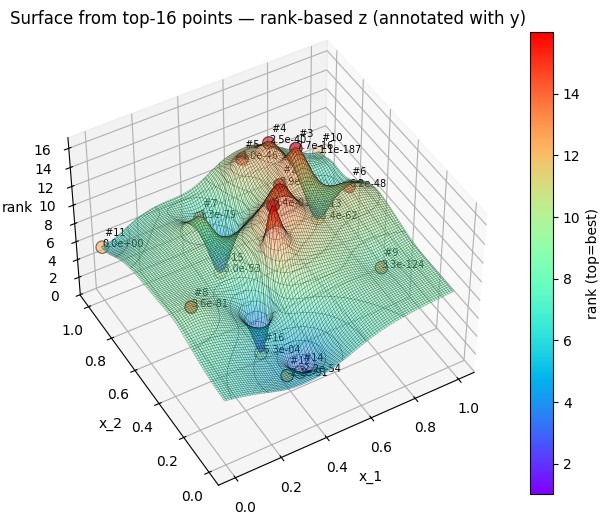

In [9]:
# ==== Evaluation grid + IDW interpolation ====

x1g = np.linspace(0, 1, n_grid)
x2g = np.linspace(0, 1, n_grid)
X1g, X2g = np.meshgrid(x1g, x2g)
grid_pts = np.column_stack([X1g.ravel(), X2g.ravel()])
candidate_pts = sample_candidates(n_cand, 2, method=CANDIDATE_SAMPLING_METHOD, seed=42)
dist_gx = np.sqrt(((grid_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w = 1.0 / (dist_gx ** 2)
Y_grid = ((w * y[None, :]).sum(axis=1) / w.sum(axis=1)).reshape(X1g.shape)

# ====  PLOTS  ====

# --- 2D plots: scatter (left) + interpolated contour (right) ---
# Use symlog only when output warping is applied; linear when warping is None (run warping cell first for WARP_LABEL)
try:
    _idw_symlog = (WARP_LABEL != "None")
except NameError:
    _idw_symlog = False
Y_grid_plot, y_levels, y_norm = _prepare_surface_for_plot(Y_grid, force_symlog=_idw_symlog)
# Norm for left scatter from observation y so points span the colormap (grid norm can make them all black)
import matplotlib.colors as mcolors
_y_flat = np.asarray(y).ravel()
_y_f = _y_flat[np.isfinite(_y_flat)]
if _y_f.size > 0:
    _ymin, _ymax = float(np.min(_y_f)), float(np.max(_y_f))
    if _idw_symlog and (_ymax > 0 or _ymin < 0):
        _scale = max(abs(_ymin), abs(_ymax), 1e-30)
        _sig = _y_f[np.abs(_y_f) > _scale * 1e-8]
        _linthresh = float(np.percentile(np.abs(_sig), 10)) if len(_sig) > 0 else _scale * 1e-4
        _linthresh = max(_linthresh, 1e-30)
        y_scatter_norm = mcolors.SymLogNorm(linthresh=_linthresh, vmin=_ymin, vmax=_ymax)
    else:
        y_scatter_norm = mcolors.Normalize(vmin=_ymin, vmax=_ymax)
else:
    y_scatter_norm = y_norm
_scale_lbl = "SymLog scale" if hasattr(y_norm, 'linthresh') else "linear"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- left plot: scatter colored by y (F3-style observations panel)
sc = ax1.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="magma", norm=y_scatter_norm, edgecolors="k", linewidths=1.5)
for i in range(len(y)):
    ax1.text(X[i, 0] + 0.02, X[i, 1] + 0.02, str(i + 1), fontsize=8, zorder=10)
ax1.set_xlabel("x_1", fontsize=10); ax1.set_ylabel("x_2", fontsize=10)
ax1.set_title("Function 1: observations", fontsize=11); ax1.set_aspect("equal")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

# --- right plot: IDW contour + observations (F3-style: red markers on contour)
cf = ax2.contourf(X1g, X2g, Y_grid_plot, levels=y_levels, norm=y_norm, cmap="magma")
ax2.contour(X1g, X2g, Y_grid_plot, levels=y_levels[::max(1, len(y_levels)//11)], colors="white", linewidths=1.0, linestyles="-", alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c='red', s=50, edgecolors="k", linewidths=1.5, zorder=5)
for i in range(len(y)):
    ax2.text(X[i, 0] + 0.02, X[i, 1] + 0.02, str(i + 1), fontsize=8, color="white", zorder=10)
ax2.set_xlabel("x_1", fontsize=10); ax2.set_ylabel("x_2", fontsize=10)
ax2.set_title("x_1 vs x_2 (interpolated)", fontsize=11)
ax2.set_aspect("equal"); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', labelsize=10)

# Shared colorbar (F3-style ScalarMappable)
sm = plt.cm.ScalarMappable(norm=y_norm, cmap="magma")
sm.set_array(y)
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=1, label=f"y ({_scale_lbl})")
cbar.ax.tick_params(labelsize=10)

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "function_1_observations.png", dpi=150)
    print("Plot saved.")
if IF_SHOW_PLOT:
    plt.show()

# ==== Top candidate regions ====
TOP_N = 16
N_TOP = min(TOP_N, len(y))
top_idx   = np.argsort(y)[::-1][:N_TOP]   # indices sorted best → worst
top_ranks = np.arange(1, N_TOP + 1)        # 1 = best
top_X, top_y = X[top_idx], y[top_idx]

# Marker size and colour scale: rank 1 is largest/brightest
sizes  = np.linspace(280, 60, N_TOP)
colors = plt.cm.YlOrRd_r(np.linspace(0.05, 0.85, N_TOP))

# ==== 3D contour surface built from top-10 points only ====
VIEW_ELEV = 45   # elevation angle (deg)
VIEW_AZIM = -120   # azimuth / rotation angle (deg); 45 for 45° rotation

dist_top = np.sqrt(((grid_pts[:, None, :] - top_X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w_top = 1.0 / (dist_top ** 2)
# Use ranks on z-axis: 3D surface with linear ranks so shape is visible
top_y_ranks = np.arange(len(top_y), 0, -1).astype(float)   # rank N = best, 1 = worst
dist_top_rank = np.sqrt(((grid_pts[:, None, :] - top_X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w_top_rank = 1.0 / (dist_top_rank ** 2)
Y_top10_rank = ((w_top_rank * top_y_ranks[None, :]).sum(axis=1) / w_top_rank.sum(axis=1)).reshape(X1g.shape)
stride = max(1, n_grid // 80)

fig4 = plt.figure(figsize=(8, 6))
ax3d = fig4.add_subplot(111, projection="3d")
surf = ax3d.plot_surface(X1g, X2g, Y_top10_rank, rstride=stride, cstride=stride, cmap="rainbow", alpha=0.5, edgecolor="black", linewidth=0.2)
ax3d.contour(X1g, X2g, Y_top10_rank, levels=min(30, N_TOP), colors="k", linewidths=0.3, alpha=0.9)
ax3d.scatter(top_X[:, 0], top_X[:, 1], top_y_ranks, c=colors, s=80, edgecolors="k", linewidths=0.8, depthshade=True)
_norm3d = plt.Normalize(Y_top10_rank.min(), Y_top10_rank.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.rainbow, norm=_norm3d)
sm.set_array(Y_top10_rank)
fig4.colorbar(sm, ax=ax3d, shrink=1).set_label("rank (top=best)", fontsize=10)

for i in range(N_TOP):
    ax3d.text(top_X[i, 0], top_X[i, 1], top_y_ranks[i], f" #{top_ranks[i]}\n{top_y[i]:.1e}", fontsize=7, ha="left")
ax3d.set_xlabel("x_1"); ax3d.set_ylabel("x_2"); ax3d.set_zlabel("rank")
ax3d.set_title(f"Surface from top-{N_TOP} points — rank-based z (annotated with y)")
ax3d.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig4.savefig(out_dir / "function_1_3d_top_points.png", dpi=150)
    print("3D plot saved.")
if IF_SHOW_PLOT:
    plt.show()


## 3. Suggest next point to submit, using Bayesian Optimization Methodology

### 3.1 Surrogate: GP kernels

We use three kernels: **RBF** (smooth), **Matérn (ν=1.5)** (rougher), **RBF + WhiteKernel** (adds observation noise). Each gives a different prior and uncertainty estimate.


In [10]:
######################################################
# Build and fit three GP kernels on (X, y) #
######################################################
# RBF: smooth isotropic  |  Matern: rougher  |  RBF+White: with explicit noise
#
# NOTE: We use optimizer=None → fixed kernel hyperparameters (no tuning).
#   - length_scale stays at LENGTH_SCALE (1.0); length_scale_bounds would have no effect.
#   - To enable tuning later: set optimizer="fmin_l_bfgs_b" and add length_scale_bounds=(1e-3, 100)
#     to each RBF/Matern so the GP can fit sharp ridges (short ℓ) and flat directions (long ℓ).

_gp_optimizer = None if not OPTIMIZE_KERNEL else 'fmin_l_bfgs_b'
_gp_n_restarts = N_RESTARTS_KERNEL if OPTIMIZE_KERNEL else 0
kernel_RBF       = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * RBF(length_scale=LENGTH_SCALE, length_scale_bounds=LENGTH_SCALE_BOUNDS)
kernel_Matern    = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * Matern(length_scale=LENGTH_SCALE, nu=MATERN_NU, length_scale_bounds=LENGTH_SCALE_BOUNDS)
kernel_RBF_noise = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * RBF(length_scale=LENGTH_SCALE, length_scale_bounds=LENGTH_SCALE_BOUNDS) + WhiteKernel(noise_level=WHITE_NOISE_LEVEL, noise_level_bounds=WHITE_NOISE_BOUNDS)

gp_RBF       = GaussianProcessRegressor(kernel=kernel_RBF,       alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)
gp_Matern    = GaussianProcessRegressor(kernel=kernel_Matern,    alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)
gp_RBF_noise = GaussianProcessRegressor(kernel=kernel_RBF_noise, alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)

gp_RBF.fit(X, y)
gp_Matern.fit(X, y)
gp_RBF_noise.fit(X, y)

# Posterior μ and σ on the visualization grid (reshaped for contour plots)
mu_gp_RBF,       sigma_gp_RBF       = gp_RBF.predict(grid_pts,        return_std=True)
mu_gp_Matern,    sigma_gp_Matern    = gp_Matern.predict(grid_pts,     return_std=True)
mu_gp_RBF_noise, sigma_gp_RBF_noise = gp_RBF_noise.predict(grid_pts,  return_std=True)

mu_gp_RBF,    sigma_gp_RBF    = mu_gp_RBF.reshape(X1g.shape),    sigma_gp_RBF.reshape(X1g.shape)
mu_gp_Matern, sigma_gp_Matern = mu_gp_Matern.reshape(X1g.shape), sigma_gp_Matern.reshape(X1g.shape)
mu_gp_RBF_noise, sigma_gp_RBF_noise = mu_gp_RBF_noise.reshape(X1g.shape), sigma_gp_RBF_noise.reshape(X1g.shape)

# Posterior on candidate_pts (for acquisition)
# Aux GPs on −y: skopt acquisition assumes minimization, so argmax acq on −y ≡ argmax y
gp_neg_RBF, gp_neg_Matern = copy.deepcopy(gp_RBF), copy.deepcopy(gp_Matern)
gp_neg_RBF_noise = copy.deepcopy(gp_RBF_noise)
gp_neg_RBF.fit(X, -y); gp_neg_Matern.fit(X, -y); gp_neg_RBF_noise.fit(X, -y)

print(75*"=")
print('Surrogate model with kernel [',GP_KERNEL,'] fitted successfully')
print(75*"=")

/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Surrogate model with kernel [ None ] fitted successfully


/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
######################################################
# Kernel selection: LML (auto) or user choice (RBF, Matern, etc.) #
######################################################
# GP_KERNEL = None or "none" → auto-select by log-marginal-likelihood (LML).
# GP_KERNEL = "RBF" | "Matern" | "RBF + WhiteKernel" (or common variants) → use that kernel.

gps = [
    (gp_RBF,       gp_neg_RBF,       "RBF"),
    (gp_Matern,    gp_neg_Matern,    "Matérn (ν=1.5)"),
    (gp_RBF_noise, gp_neg_RBF_noise, "RBF + WhiteKernel"),
]
CANONICAL_NAMES = ["RBF", "Matérn (ν=1.5)", "RBF + WhiteKernel"]
# Map user input (normalized) to canonical name
KERNEL_ALIASES = {
    "rbf": "RBF",
    "matern": "Matérn (ν=1.5)",
    "matérn (ν=1.5)": "Matérn (ν=1.5)",
    "matern (ν=1.5)": "Matérn (ν=1.5)",
    "rbf + whitekernel": "RBF + WhiteKernel",
    "rbf+whitekernel": "RBF + WhiteKernel",
    "rbf + white": "RBF + WhiteKernel",
    "white": "RBF + WhiteKernel",
}

def _normalize_kernel_input(val):
    if val is None:
        return None
    s = str(val).strip()
    if s.lower() in ("none", ""):
        return None
    return s

def _resolve_kernel_name(user_input):
    if user_input is None:
        return None
    key = user_input.lower().strip()
    if key in KERNEL_ALIASES:
        return KERNEL_ALIASES[key]
    if user_input in CANONICAL_NAMES:
        return user_input
    for c in CANONICAL_NAMES:
        if c.lower() == key or key in c.lower():
            return c
    return None

use_lml = _normalize_kernel_input(GP_KERNEL) is None

if use_lml:
    print(75*"=")
    print("Kernel selection via log-marginal-likelihood (LML)")
    print(75*"=")
    lml_scores = {name: gp.log_marginal_likelihood_value_ for gp, _, name in gps}
    best_name  = max(lml_scores, key=lml_scores.get)
    print("Log-marginal-likelihood per kernel:")
    for name, lml in lml_scores.items():
        marker = "  ← best" if name == best_name else ""
        print(f"  {name:<22}: {lml:.4f}{marker}")
    print(f"\nAuto-selected kernel: {best_name}")
else:
    resolved = _resolve_kernel_name(_normalize_kernel_input(GP_KERNEL))
    if resolved is None:
        print(f"Unknown kernel '{GP_KERNEL}'. Choose from: {CANONICAL_NAMES}. Falling back to LML.")
        lml_scores = {name: gp.log_marginal_likelihood_value_ for gp, _, name in gps}
        best_name = max(lml_scores, key=lml_scores.get)
    else:
        best_name = resolved
        print(75*"=")
        print(f"Kernel selection by user: {best_name}")
        print(75*"=")

best_gp     = next(gp  for gp, _, name in gps if name == best_name)
best_gp_neg = next(gn  for _,  gn, name in gps if name == best_name and gn is not None)
print(f"  Fitted kernel: {best_gp.kernel_}")
print(75*"=")
print("Kernel set done.")



Kernel selection via log-marginal-likelihood (LML)
Log-marginal-likelihood per kernel:
  RBF                   : -24.1220
  Matérn (ν=1.5)        : -24.1220
  RBF + WhiteKernel     : -24.1220  ← best

Auto-selected kernel: RBF + WhiteKernel
  Fitted kernel: 0.485**2 * RBF(length_scale=0.01) + WhiteKernel(noise_level=0.765)
Kernel set done.


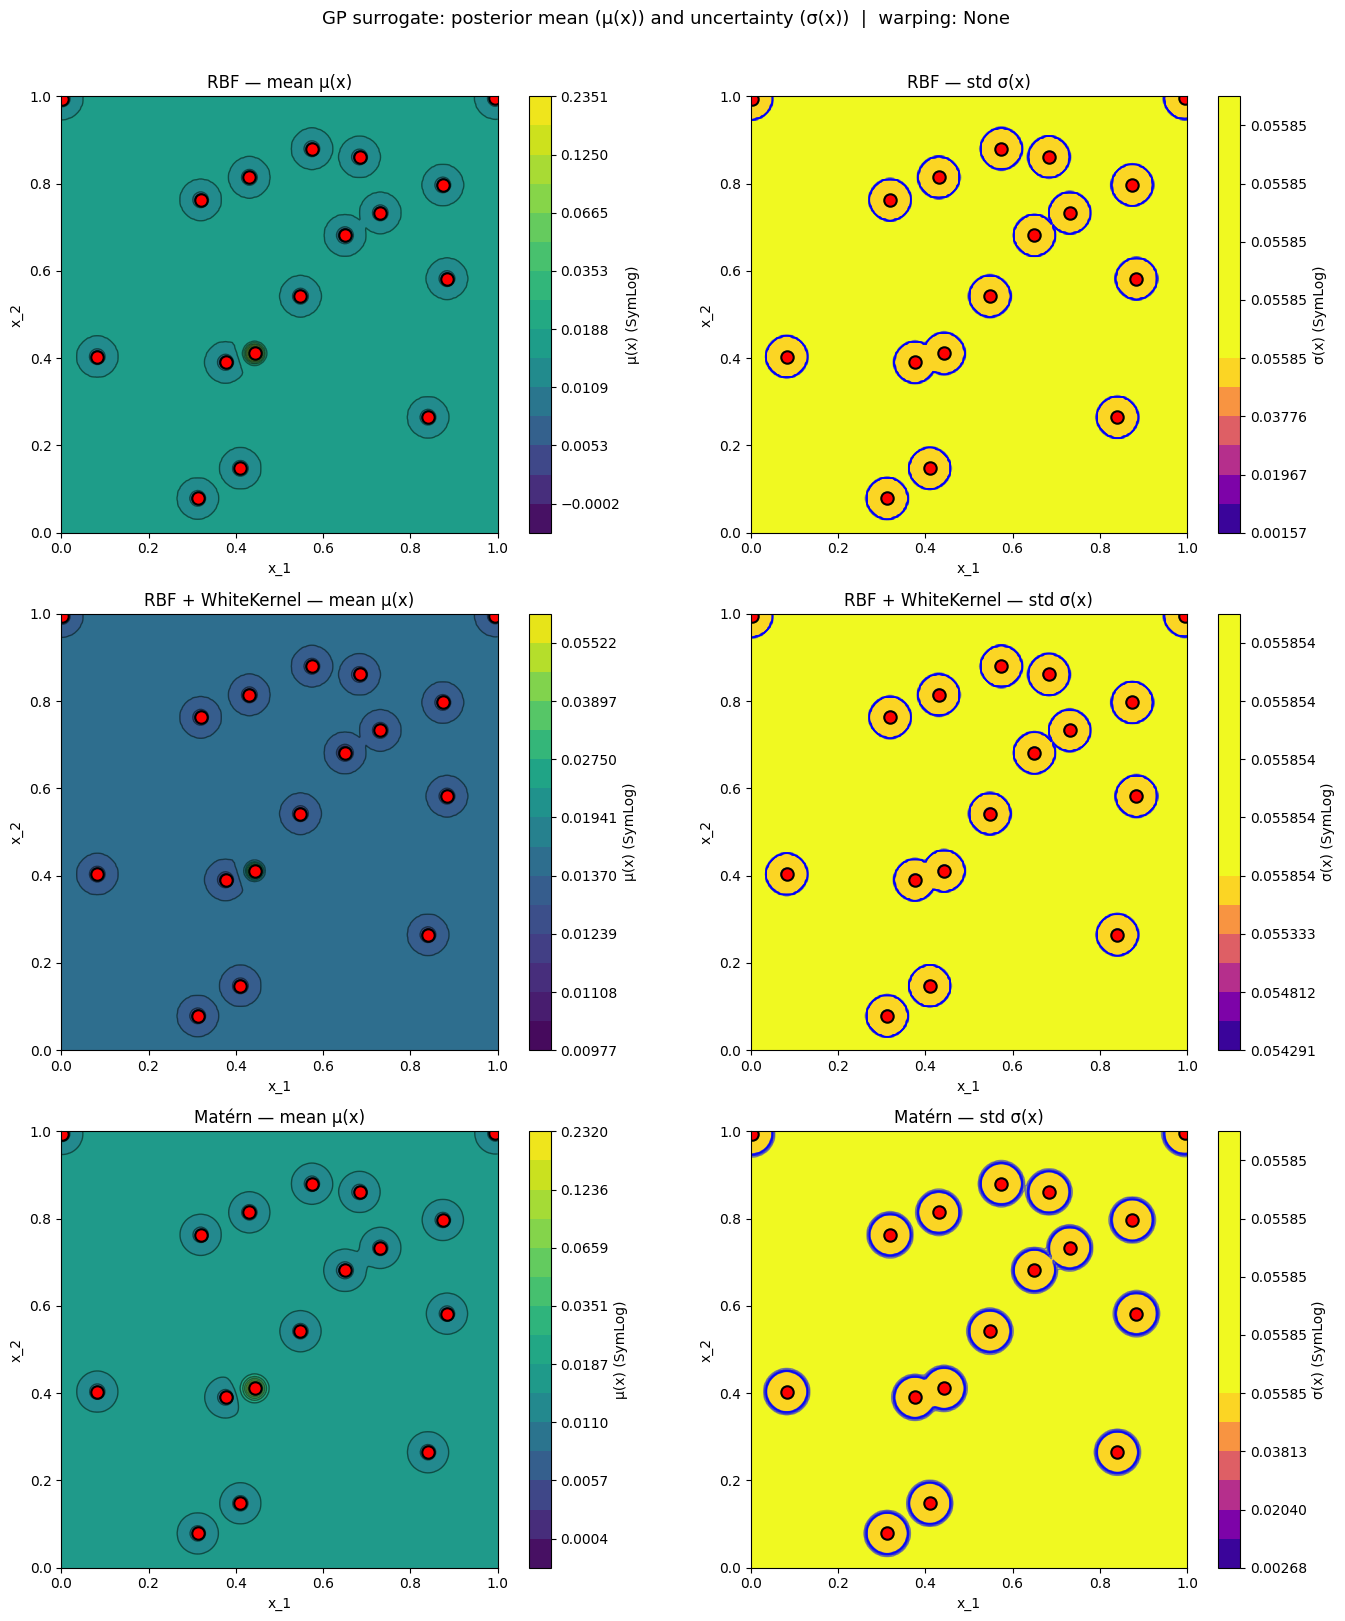

In [12]:
####################################################
# PLOT GP posterior: μ(x) and σ(x) for each kernel #    
####################################################

kernels_info = [
    (mu_gp_RBF,       sigma_gp_RBF,       "RBF"),
    (mu_gp_RBF_noise, sigma_gp_RBF_noise, "RBF + WhiteKernel"),
    (mu_gp_Matern,    sigma_gp_Matern,    "Matérn"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
for i, (mu, sig, name) in enumerate(kernels_info):
    ax_mu, ax_sig = axes[i, 0], axes[i, 1]

    mu_p,  mu_lvl,  mu_nrm  = _prepare_surface_for_plot(mu, force_symlog=True)
    sig_p, sig_lvl, sig_nrm = _prepare_surface_for_plot(sig, force_symlog=True)
    _mu_sl  = "SymLog" if hasattr(mu_nrm,  'linthresh') else "linear"
    _sig_sl = "SymLog" if hasattr(sig_nrm, 'linthresh') else "linear"
    _mu_cl  = mu_lvl[::max(1, len(mu_lvl)  // 11)]
    _sig_cl = sig_lvl[::max(1, len(sig_lvl) // 11)]

    # Mean panel
    cf1 = ax_mu.contourf(X1g, X2g, mu_p, levels=mu_lvl, norm=mu_nrm, cmap="viridis")
    ax_mu.contour(X1g, X2g, mu_p, levels=_mu_cl, colors="k", linewidths=1.0, alpha=0.5, linestyles="-")
    fig.colorbar(cf1, ax=ax_mu).set_label(f"μ(x) ({_mu_sl})", fontsize=10)
    ax_mu.scatter(X[:, 0], X[:, 1], c="red", s=80, edgecolors="k", zorder=2, linewidths=1.5)
    ax_mu.set_xlabel("x_1", fontsize=10); ax_mu.set_ylabel("x_2", fontsize=10)
    ax_mu.set_title(f"{name} — mean μ(x)", fontsize=12)
    ax_mu.set_aspect("equal")

    # Std panel
    cf2 = ax_sig.contourf(X1g, X2g, sig_p, levels=sig_lvl, norm=sig_nrm, cmap="plasma")
    ax_sig.contour(X1g, X2g, sig_p, levels=_sig_cl, colors="blue", linewidths=1.0, alpha=0.5, linestyles="-")
    fig.colorbar(cf2, ax=ax_sig).set_label(f"σ(x) ({_sig_sl})", fontsize=10)
    ax_sig.scatter(X[:, 0], X[:, 1], c="red", s=80, edgecolors="k", zorder=2, linewidths=1.5)
    ax_sig.set_xlabel("x_1", fontsize=10); ax_sig.set_ylabel("x_2", fontsize=10)
    ax_sig.set_title(f"{name} — std σ(x)", fontsize=12)
    ax_sig.set_aspect("equal")

fig.suptitle(f"GP surrogate: posterior mean (μ(x)) and uncertainty (σ(x))  |  warping: {WARP_LABEL}", fontsize=13, y=1.01)
fig.tight_layout()

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "function_1_gp_three_kernels.png"
    fig.savefig(out_path, dpi=150, format="png", bbox_inches="tight")
    print("Plot saved to", out_path)
if IF_SHOW_PLOT:
    plt.show()




### 3.2 Acquisition functions

EI (Expected Improvement), UCB (Upper Confidence Bound), PI (Probability of Improvement).


In [13]:
# ==== Acquisition functions (skopt, on −y GPs) ====
y_best = best_y
print(75*'=')
print('Select the acquisition functions to be used:')
print(75*'=')

# ---- EI: E[max(f(x) − f(x⁺), 0)] for each kernel ----
EI_RBF          = gaussian_ei(candidate_pts, gp_neg_RBF,    y_opt=-y_best, xi=XI_EI_PI)
EI_RBF_noise    = gaussian_ei(candidate_pts, gp_neg_RBF_noise,    y_opt=-y_best, xi=XI_EI_PI)
EI_Matern       = gaussian_ei(candidate_pts, gp_neg_Matern, y_opt=-y_best, xi=XI_EI_PI)

# ---- PI: P(f(x) > f(x⁺) + ξ) for each kernel ----
PI_RBF          = gaussian_pi(candidate_pts, gp_neg_RBF,    y_opt=-y_best, xi=XI_EI_PI)
PI_RBF_noise    = gaussian_pi(candidate_pts, gp_neg_RBF_noise,    y_opt=-y_best, xi=XI_EI_PI)
PI_Matern       = gaussian_pi(candidate_pts, gp_neg_Matern, y_opt=-y_best, xi=XI_EI_PI)

# ---- LCB: minimize μ(x) − κσ(x) on −y ≡ maximize UCB of y ----
LCB_RBF         = gaussian_lcb(candidate_pts, gp_neg_RBF,    kappa=KAPPA_UCB)
LCB_RBF_noise   = gaussian_lcb(candidate_pts, gp_neg_RBF_noise,    kappa=KAPPA_UCB)
LCB_Matern      = gaussian_lcb(candidate_pts, gp_neg_Matern, kappa=KAPPA_UCB)

# ---- Mask candidates too close to existing observations (avoid re-evaluating) ----
min_dist_cand = np.min(np.sqrt(((candidate_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)), axis=1)
next_x_high_dist = np.clip(np.asarray(candidate_pts[np.argmax(min_dist_cand)]).ravel(), 0.0, 0.999999)
too_close = min_dist_cand < MIN_DIST_THRESHOLD
try: BOUNDARY_MARGIN
except NameError: BOUNDARY_MARGIN = 0
# ---- Optional: mask candidates near domain boundaries (GP extrapolation poor; useful for low-d only) ----
near_boundary = np.any((candidate_pts <= BOUNDARY_MARGIN) | (candidate_pts >= 1.0 - BOUNDARY_MARGIN), axis=1) if BOUNDARY_MARGIN > 0 else np.zeros(len(candidate_pts), dtype=bool)
masked = too_close | near_boundary
EI_RBF[masked] = EI_RBF_noise[masked] = EI_Matern[masked] = -np.inf
PI_RBF[masked] = PI_RBF_noise[masked] = PI_Matern[masked] = -np.inf
LCB_RBF[masked] = LCB_RBF_noise[masked] = LCB_Matern[masked] = np.inf

def _pick(acq_val, maximize, fallback):
    idx = np.argmax(acq_val) if maximize else np.argmin(acq_val)
    return np.asarray(fallback).ravel() if masked[idx] else candidate_pts[idx]

x_best_EI_RBF           = _pick(EI_RBF, True, next_x_high_dist)
x_best_EI_RBF_noise     = _pick(EI_RBF_noise, True, next_x_high_dist)
x_best_EI_Matern        = _pick(EI_Matern, True, next_x_high_dist)
x_best_PI_RBF           = _pick(PI_RBF, True, next_x_high_dist)
x_best_PI_RBF_noise     = _pick(PI_RBF_noise, True, next_x_high_dist)
x_best_PI_Matern        = _pick(PI_Matern, True, next_x_high_dist)
x_best_UCB_RBF          = _pick(LCB_RBF, False, next_x_high_dist)
x_best_UCB_RBF_noise    = _pick(LCB_RBF_noise, False, next_x_high_dist)
x_best_UCB_Matern       = _pick(LCB_Matern, False, next_x_high_dist)

is_rbf    = (best_name == "RBF")
is_rbf_w  = (best_name == "RBF + WhiteKernel")
is_matern = (best_name == "Matérn (ν=1.5)" or "Matérn" in best_name)

print(f"\nFrom Log-Marginal-Likelihood selection, the best GP is: {best_name}")
print('\nAcquisition functions predictions for each kernel and GP:')
print(f'\nGP with RBF kernel: selected = {str(is_rbf).upper()}')
print(f"    EI  (RBF):   next x1 = {x_best_EI_RBF[0]:.3f}, x2 = {x_best_EI_RBF[1]:.3f}")
print(f"    PI  (RBF):   next x1 = {x_best_PI_RBF[0]:.3f}, x2 = {x_best_PI_RBF[1]:.3f}")
print(f"    UCB (RBF):   next x1 = {x_best_UCB_RBF[0]:.3f}, x2 = {x_best_UCB_RBF[1]:.3f}")
print(f'\nGP with RBF + WhiteKernel: selected = {str(is_rbf_w).upper()}')
print(f"    EI  (RBF + WhiteKernel):   next x1 = {x_best_EI_RBF_noise[0]:.3f}, x2 = {x_best_EI_RBF_noise[1]:.3f}")
print(f"    PI  (RBF + WhiteKernel):   next x1 = {x_best_PI_RBF_noise[0]:.3f}, x2 = {x_best_PI_RBF_noise[1]:.3f}")
print(f"    UCB (RBF + WhiteKernel):   next x1 = {x_best_UCB_RBF_noise[0]:.3f}, x2 = {x_best_UCB_RBF_noise[1]:.3f}")
print(f'\nGP with Matérn kernel: selected = {str(is_matern).upper()}')
print(f"    EI  (Matern):   next x1 = {x_best_EI_Matern[0]:.3f}, x2 = {x_best_EI_Matern[1]:.3f}")
print(f"    PI  (Matern):   next x1 = {x_best_PI_Matern[0]:.3f}, x2 = {x_best_PI_Matern[1]:.3f}")
print(f"    UCB (Matern):   next x1 = {x_best_UCB_Matern[0]:.3f}, x2 = {x_best_UCB_Matern[1]:.3f}")
print(75*'=')


Select the acquisition functions to be used:

From Log-Marginal-Likelihood selection, the best GP is: RBF + WhiteKernel

Acquisition functions predictions for each kernel and GP:

GP with RBF kernel: selected = FALSE
    EI  (RBF):   next x1 = 0.445, x2 = 0.421
    PI  (RBF):   next x1 = 0.445, x2 = 0.421
    UCB (RBF):   next x1 = 0.445, x2 = 0.421

GP with RBF + WhiteKernel: selected = TRUE
    EI  (RBF + WhiteKernel):   next x1 = 0.445, x2 = 0.421
    PI  (RBF + WhiteKernel):   next x1 = 0.445, x2 = 0.421
    UCB (RBF + WhiteKernel):   next x1 = 0.445, x2 = 0.421

GP with Matérn kernel: selected = FALSE
    EI  (Matern):   next x1 = 0.445, x2 = 0.421
    PI  (Matern):   next x1 = 0.445, x2 = 0.421
    UCB (Matern):   next x1 = 0.445, x2 = 0.421


### 3.3 Acquisition function surfaces

EI and UCB heatmaps over the full grid — shows *where* each strategy wants to query, not just the argmax point.

Next query (argmax) uses candidate points sampled with: sobol
Solo mode: showing selected acquisition: EI


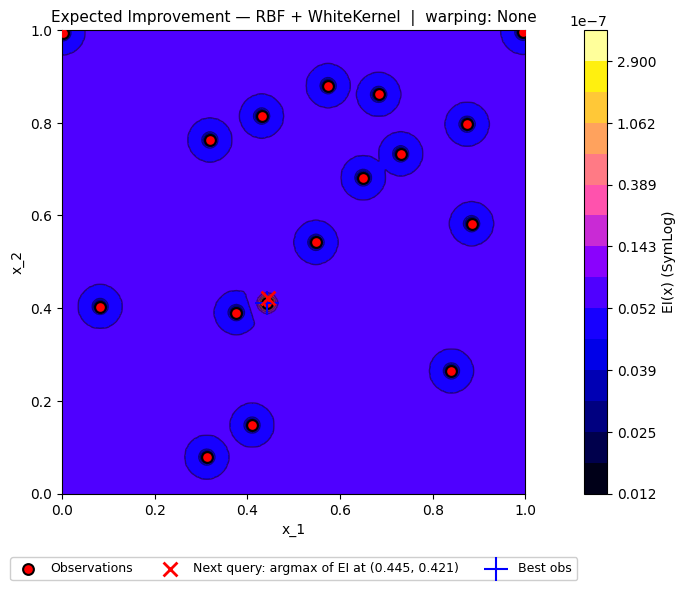

In [14]:
##############################################################
# Acquisition surface plot(s): solo (1 panel) or ensemble (3 panels) #
##############################################################

print(75*'=')
print("Next query (argmax) uses candidate points sampled with:", CANDIDATE_SAMPLING_METHOD)
if USE_ENSEMBLE:
    print("Ensemble mode: showing EI, PI, UCB heatmaps.")
else:
    print("Solo mode: showing selected acquisition:", SOLO_STRATEGY)
print(75*'=')

EI_grid  = gaussian_ei(grid_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
PI_grid  = gaussian_pi(grid_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
LCB_grid = gaussian_lcb(grid_pts, best_gp_neg, kappa=KAPPA_UCB)
UCB_grid = -LCB_grid

EI_surf  = EI_grid.reshape(X1g.shape)
PI_surf  = PI_grid.reshape(X1g.shape)
UCB_surf = UCB_grid.reshape(X1g.shape)

# Argmax from selected kernel
x_best_EI  = x_best_EI_RBF if is_rbf else (x_best_EI_RBF_noise if is_rbf_w else x_best_EI_Matern)
x_best_PI  = x_best_PI_RBF if is_rbf else (x_best_PI_RBF_noise if is_rbf_w else x_best_PI_Matern)
x_best_UCB = x_best_UCB_RBF if is_rbf else (x_best_UCB_RBF_noise if is_rbf_w else x_best_UCB_Matern)

if USE_ENSEMBLE:
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 13))
    for ax, surf, x_argmax, label, title in [
        (ax1, EI_surf,  x_best_EI,  "EI(x)",  "Expected Improvement"),
        (ax2, PI_surf,  x_best_PI,  "PI(x)",  "Probability of Improvement"),
        (ax3, UCB_surf, x_best_UCB, "UCB(x)", "Upper Confidence Bound"),
    ]:
        surf_plot, acq_levels, acq_norm = _prepare_surface_for_plot(surf, force_symlog=True)
        cf = ax.contourf(X1g, X2g, surf_plot, levels=acq_levels, norm=acq_norm, cmap="gnuplot2")
        ax.contour(X1g, X2g, surf_plot, levels=acq_levels[::max(1,len(acq_levels)//11)], colors="k", linewidths=1.0, alpha=0.5)
        _sl = "SymLog" if hasattr(acq_norm, 'linthresh') else "linear"
        fig.colorbar(cf, ax=ax).set_label(f"{label} ({_sl})", fontsize=10)
        ax.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5, label="Observations", linewidths=1.5)
        ax.scatter(*x_argmax, s=200, marker="x", c="red", zorder=10, label="argmax", linewidths=2)
        ax.scatter(*best_x_so_far, s=300, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")
        ax.set_xlabel("x_1", fontsize=10); ax.set_ylabel("x_2", fontsize=10)
        ax.set_title(f"{title} — {best_name}  |  warping: {WARP_LABEL}", fontsize=11)
        ax.legend(fontsize=9, loc="upper right", framealpha=0.95, bbox_to_anchor=(1, -0.25), ncol=3, borderaxespad=0.1)
    fig.suptitle(f"Acquisition surfaces (ensemble mode)  |  warping: {WARP_LABEL}", fontsize=12)
else:
    _acq_display = {
        "EI":  (EI_surf,  x_best_EI,  "EI(x)",  "Expected Improvement"),
        "PI":  (PI_surf,  x_best_PI,  "PI(x)",  "Probability of Improvement"),
        "UCB": (UCB_surf, x_best_UCB, "UCB(x)", "Upper Confidence Bound"),
    }
    surf, x_argmax, cbar_label, title_name = _acq_display.get(SOLO_STRATEGY, _acq_display["EI"])
    surf_plot, acq_levels, acq_norm = _prepare_surface_for_plot(surf, force_symlog=True)
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    cf = ax.contourf(X1g, X2g, surf_plot, levels=acq_levels, norm=acq_norm, cmap="gnuplot2")
    ax.contour(X1g, X2g, surf_plot, levels=acq_levels[::max(1,len(acq_levels)//11)], colors="k", linewidths=1.0, alpha=0.5, linestyles="-")
    _sl = "SymLog" if hasattr(acq_norm, 'linthresh') else "linear"
    fig.colorbar(cf, ax=ax).set_label(f"{cbar_label} ({_sl})", fontsize=10)
    ax.scatter(X[:, 0], X[:, 1], c="r", s=60, edgecolors="k", zorder=5, label="Observations", linewidths=1.5)
    ax.scatter(*x_argmax, s=100, marker="x", c="red", zorder=10, label=f"Next query: argmax of {SOLO_STRATEGY} at ({x_argmax[0]:.3f}, {x_argmax[1]:.3f})", linewidths=2)
    ax.set_xlabel("x_1", fontsize=10); ax.set_ylabel("x_2", fontsize=10)
    ax.scatter(*best_x_so_far, s=300, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")
    ax.set_title(f"{title_name} — {best_name}  |  warping: {WARP_LABEL}", fontsize=11)
    ax.legend(fontsize=9, loc='lower center', framealpha=0.95, bbox_to_anchor=(0.5, -0.2), ncol=3)
    ax.set_aspect("equal")

fig.tight_layout()
if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = "function_1_acquisition_ensemble.png" if USE_ENSEMBLE else "function_1_acquisition_surface.png"
    fig.savefig(out_dir / fname, dpi=150, bbox_inches="tight")
    print("Saved acquisition surface plot")
if IF_SHOW_PLOT:
    plt.show()


In [15]:
# Warn if posterior uncertainty is near zero (EI/PI collapse to near-zero suggestions)
sigma_max = max(np.nanmax(sigma_gp_RBF), np.nanmax(sigma_gp_Matern), np.nanmax(sigma_gp_RBF_noise))
if sigma_max < 1e-6:
    print(f"Low GP σ ({sigma_max:.2e}); EI/PI may be degenerate.")


### Pairwise distances between suggestions (small = agree)

In [16]:
# Pairwise L2 distances between all suggested points (small = strategies agree)
names = ['EI', 'UCB', 'PI']
pts = [np.asarray(x).ravel() for x in [x_best_EI, x_best_UCB, x_best_PI]]
n_pts = len(pts)
dists = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    for j in range(n_pts):
        dists[i, j] = np.linalg.norm(pts[i] - pts[j])
for i in range(n_pts):
    for j in range(i + 1, n_pts):
        print(f"  {names[i]} vs {names[j]}: {dists[i, j]:.4f}")
max_d = dists.max()
if max_d < AGREE_THRESHOLD:
    print(f"\n>>> Suggestions agree (max pairwise dist = {max_d:.4f} < {AGREE_THRESHOLD}).")
else:
    print(f"\n>>> Suggestions differ (max dist = {max_d:.4f}); compare strategies.")


  EI vs UCB: 0.0000
  EI vs PI: 0.0000
  UCB vs PI: 0.0000

>>> Suggestions agree (max pairwise dist = 0.0000 < 0.15).


## 4. Select next query

Ensemble: EI, PI, UCB agree → use EI; disagree → use centroid. See `docs_private/ENSEMBLE_ACQUISITION_GUIDE.md`.


In [17]:
# ==== §4 Select next query ====
# EI, PI, UCB: if max pairwise L2 distance < AGREE_THRESHOLD → use EI; else → centroid.
# Toggle USE_ENSEMBLE / SOLO_STRATEGY in the parameters cell above.
# Uses best kernel's argmax (x_best_EI, x_best_PI, x_best_UCB from acquisition cell §3).
# Masking (MIN_DIST_THRESHOLD + BOUNDARY_MARGIN) was already applied in §3 via _pick.
x_EI  = np.asarray(x_best_EI).ravel()
x_PI  = np.asarray(x_best_PI).ravel()
x_UCB = np.asarray(x_best_UCB).ravel()
pts = np.array([x_EI, x_PI, x_UCB])
d12 = np.linalg.norm(pts[0] - pts[1])
d13 = np.linalg.norm(pts[0] - pts[2])
d23 = np.linalg.norm(pts[1] - pts[2])
max_d = max(d12, d13, d23)

# Without ensemble: use SOLO_STRATEGY
_solo_map = {"EI": x_EI, "PI": x_PI, "UCB": x_UCB}
next_x_no_ens = np.clip(_solo_map.get(SOLO_STRATEGY, x_EI).copy(), 0.0, 0.999999)
# With ensemble: centroid if disagree, else EI
next_x_with_ens = np.clip(np.mean(pts, axis=0), 0.0, 0.999999) if max_d >= AGREE_THRESHOLD else np.clip(x_EI.copy(), 0.0, 0.999999)

print(f"Without ensemble ({SOLO_STRATEGY}):  x = ({next_x_no_ens[0]:.4f}, {next_x_no_ens[1]:.4f})")
print(f"With ensemble: EI=({x_EI[0]:.4f},{x_EI[1]:.4f}), PI=({x_PI[0]:.4f},{x_PI[1]:.4f}), UCB=({x_UCB[0]:.4f},{x_UCB[1]:.4f}) → max_dist={max_d:.4f}")
print(f"  → {'centroid' if max_d >= AGREE_THRESHOLD else 'all agree → EI'} = ({next_x_with_ens[0]:.4f}, {next_x_with_ens[1]:.4f})")

# Use chosen mode (USE_ENSEMBLE) for downstream
next_x = next_x_with_ens if USE_ENSEMBLE else next_x_no_ens

# Proximity check: only replace with fallback for near-duplicates (avoid submitting same point twice).
DUPLICATE_THRESHOLD = 1e-3
dist_to_obs = np.sqrt(((X - next_x) ** 2).sum(axis=1))
nearest_idx  = np.argmin(dist_to_obs)
nearest_dist = dist_to_obs[nearest_idx]
if nearest_dist < DUPLICATE_THRESHOLD:
    print(f"\u26a0 Proposed point is duplicate (dist={nearest_dist:.2e} to obs #{nearest_idx+1}); using high-dist fallback.")
    next_x = next_x_high_dist
elif nearest_dist < MIN_DIST_THRESHOLD:
    print(f"  (Proposed point is {nearest_dist:.4f} from obs #{nearest_idx+1} — keeping it.)")

_strat = 'ensemble' if USE_ENSEMBLE else SOLO_STRATEGY
print(f"Next query | kernel: {best_name} | strategy: {_strat} | xi={XI_EI_PI}")
print(f"  x = ({next_x[0]:.4f}, {next_x[1]:.4f})")
print(f"  Nearest existing obs: #{nearest_idx+1} at dist={nearest_dist:.4f}")
print(f"  Current best y = {best_y:.4g} at ({best_x_so_far[0]:.4f}, {best_x_so_far[1]:.4f})")


Without ensemble (EI):  x = (0.4447, 0.4209)
With ensemble: EI=(0.4447,0.4209), PI=(0.4447,0.4209), UCB=(0.4447,0.4209) → max_dist=0.0000
  → all agree → EI = (0.4447, 0.4209)
Next query | kernel: RBF + WhiteKernel | strategy: EI | xi=0.05
  x = (0.4447, 0.4209)
  Nearest existing obs: #16 at dist=0.0100
  Current best y = 0.2371 at (0.4430, 0.4110)


## 5. Illustrate the locations on the proposed query

Proposed query: x1 = 0.444679,  x2 = 0.420876
Strategy      : EI  (max pairwise dist = 0.0000)
Portal string : 0.444679-0.420876


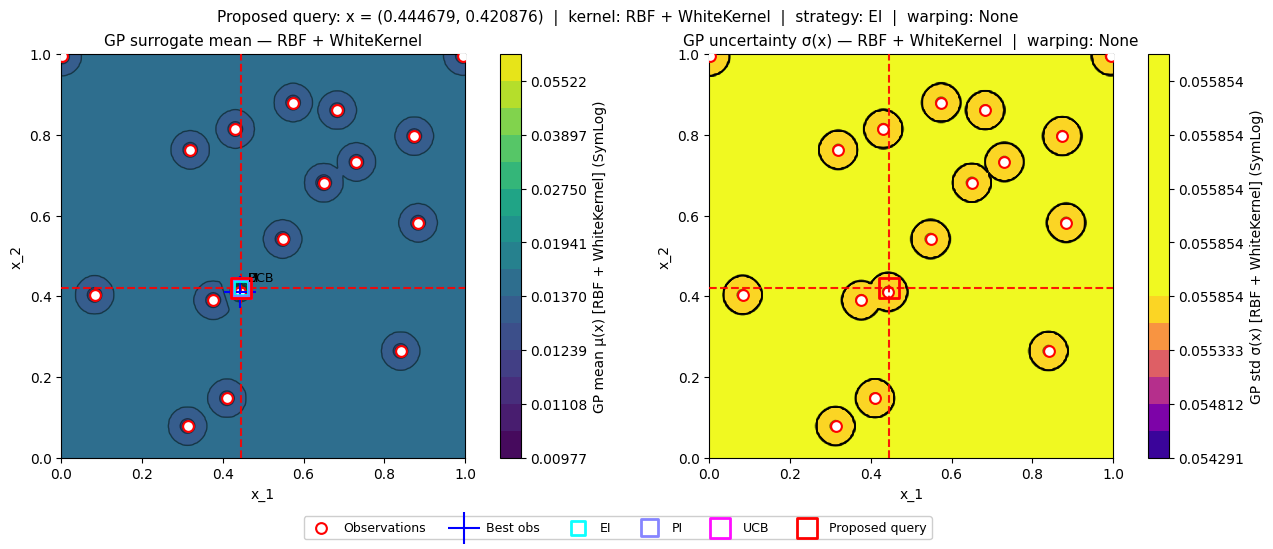

In [18]:
# ==== Summary plot: GP posterior mean (left) + GP uncertainty σ (right) ====
# Left:  GP mean μ(x) — where the surrogate predicts the objective is high.
# Right: GP std  σ(x) — where the model is uncertain (drives exploration).
# next_x (proposed query) is overlaid on both panels.

# next_x is set in Section 4 (Select next query); fallback if that cell was skipped
try:
    _ = next_x
except NameError:
    _ei = gaussian_ei(candidate_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
    next_x = np.clip(np.asarray(candidate_pts[np.argmax(_ei)]).ravel(), 0.0, 0.999999)

_method = CANDIDATE_SAMPLING_METHOD

# Select best-kernel surfaces (already computed in GP fitting cell)
mu_best    = (mu_gp_RBF    if best_name == "RBF"
              else mu_gp_Matern    if "Matérn" in best_name
              else mu_gp_RBF_noise)
sigma_best = (sigma_gp_RBF if best_name == "RBF"
              else sigma_gp_Matern if "Matérn" in best_name
              else sigma_gp_RBF_noise)

# Acquisition argmax points (EI, PI, UCB) for overlay
suggestions_pts = [x_best_EI, x_best_PI, x_best_UCB]
suggestions_lbl = ["EI", "PI", "UCB"]
colors_combined = plt.cm.cool(np.linspace(0, 1, len(suggestions_pts)))
markers_size = [100, 150, 200]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

mu_plot, mu_levels, mu_norm = _prepare_surface_for_plot(mu_best, force_symlog=True)
sigma_plot, sigma_levels, sigma_norm = _prepare_surface_for_plot(sigma_best, force_symlog=True)
_mu_sl    = "SymLog" if hasattr(mu_norm,    'linthresh') else "linear"
_sigma_sl = "SymLog" if hasattr(sigma_norm, 'linthresh') else "linear"

# ── Left: GP posterior mean ───────────────────────────────────────────────
cf1 = ax1.contourf(X1g, X2g, mu_plot, levels=mu_levels, norm=mu_norm, cmap="viridis")
ax1.contour(X1g, X2g, mu_plot, levels=mu_levels[::max(1,len(mu_levels)//11)], colors="k", linewidths=1.0, alpha=0.5, linestyles="-")
fig.colorbar(cf1, ax=ax1).set_label(f"GP mean μ(x) [{best_name}] ({_mu_sl})", fontsize=10)
ax1.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5, linewidths=1.5, label="Observations")
ax1.scatter(*best_x_so_far, s=500, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")

for pt, lbl, col, size in zip(suggestions_pts, suggestions_lbl, colors_combined, markers_size):
    ax1.scatter(pt[0], pt[1], s=size, marker="s", c='none', edgecolors=[col],linewidths=2.0, alpha=0.95, zorder=10, label=lbl)
    ax1.annotate(lbl, (pt[0], pt[1]), xytext=(5, 5), textcoords="offset points", fontsize=9, zorder=11)
ax1.scatter(next_x[0], next_x[1], facecolors="none", s=200, marker="s", edgecolors="red",linewidths=2, zorder=12, label="Proposed query")
ax1.axvline(next_x[0], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax1.axhline(next_x[1], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax1.set_xlabel("x_1", fontsize=10); ax1.set_ylabel("x_2", fontsize=10)
ax1.set_title(f"GP surrogate mean — {best_name}", fontsize=11)
ax1.set_aspect("equal")

# ── Right: GP posterior std ───────────────────────────────────────────────
cf2 = ax2.contourf(X1g, X2g, sigma_plot, levels=sigma_levels, norm=sigma_norm, cmap="plasma")
ax2.contour(X1g, X2g, sigma_plot, levels=sigma_levels[::max(1,len(sigma_levels)//11)], colors="k", linewidths=1.0, alpha=0.5, linestyles="-")
fig.colorbar(cf2, ax=ax2).set_label(f"GP std σ(x) [{best_name}] ({_sigma_sl})", fontsize=10)
ax2.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5,linewidths=1.5, label="Observations")
ax2.scatter(next_x[0], next_x[1], facecolors="none", s=200, marker="s", edgecolors="red",
            linewidths=2, zorder=12, label="Proposed query")
ax2.axvline(next_x[0], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax2.axhline(next_x[1], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax2.set_xlabel("x_1", fontsize=10); ax2.set_ylabel("x_2", fontsize=10)
ax2.set_title(f"GP uncertainty σ(x) — {best_name}  |  warping: {WARP_LABEL}", fontsize=11)
ax2.set_aspect("equal")

# Shared legend
handles1, labels1 = ax1.get_legend_handles_labels()
fig.legend(handles1, labels1, loc="lower center", bbox_to_anchor=(0.5, -0.08),
           ncol=7, fontsize=9, frameon=True, framealpha=0.95)
_strat_label = ("ensemble — centroid" if (USE_ENSEMBLE and max_d >= AGREE_THRESHOLD)
                else "ensemble — EI (agreed)" if USE_ENSEMBLE
                else SOLO_STRATEGY)
fig.suptitle(
    f"Proposed query: x = ({next_x[0]:.6f}, {next_x[1]:.6f})  |  "
    f"kernel: {best_name}  |  strategy: {_strat_label}  |  warping: {WARP_LABEL}",
    fontsize=11
)
print(f"Proposed query: x1 = {next_x[0]:.6f},  x2 = {next_x[1]:.6f}")
print(f"Strategy      : {_strat_label}  (max pairwise dist = {max_d:.4f})")
print(f"Portal string : {next_x[0]:.6f}-{next_x[1]:.6f}")
if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "function_1_all_acquisition_points.png",
                dpi=150, format="png", bbox_inches="tight")
    print("Plot saved")
if IF_SHOW_PLOT:
    plt.show()


In [19]:
# Save next query: .npy for downstream code, .txt for the portal submission form
if IF_EXPORT_QUERIES:
    # Build solver registry: MyBO is always available; Optuna/TuRBO/GA require Section 6
    _solutions = {"MyBO": np.asarray(next_x).ravel()}
    try:
        _solutions.update({name: np.asarray(x_pt).ravel() for name, x_pt in suggestions})
    except NameError:
        pass  # Section 6 not yet run — only MyBO available

    if NEXT_QUERY_SOLUTION not in _solutions:
        print(f"\u26a0  NEXT_QUERY_SOLUTION='{NEXT_QUERY_SOLUTION}' not in {list(_solutions.keys())}; "
              f"run Section 6 first or change the flag. Falling back to MyBO.")
    _export_x = _solutions.get(NEXT_QUERY_SOLUTION, _solutions["MyBO"])

    next_x_clip = np.clip(np.asarray(_export_x, dtype=np.float64).ravel(), 0.0, 0.999999)
    portal_str = "-".join(f"{v:.6f}" for v in next_x_clip)
    out_dir = repo_root / "data" / "submissions" / "function_1"
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "next_input.npy", next_x_clip)
    (out_dir / "next_input_portal.txt").write_text(portal_str)
    print(f"Saved [{NEXT_QUERY_SOLUTION}]. Portal string: {portal_str}")
    print(f"  Available solvers: {list(_solutions.keys())}")
else:
    print("IF_EXPORT_QUERIES=False; not saved.")


Saved [MyBO]. Portal string: 0.444679-0.420876
  Available solvers: ['MyBO']


## 6. MyBO vs Open Source Commonly Used Optimization Solvers

Run **MyBO** (classical BO: this notebook’s pipeline = GP + EI/PI/UCB pipeline), **Optuna** (TPE), **TuRBO**, and **GA** (evolutionary/DE maximize GP-EI) on the same data. **Summary figure:** Left panel = observations coloured by y (magma, scale from observation y range), grey edges; best observation is one of the points (no separate "+" marker). Right panel = IDW-interpolated y contour with white observation markers, best "+" highlighted, and MyBO/Optuna/TuRBO/GA suggested next points overlaid. Shared colorbar.

OMP: pid 70537 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 70537 tid 13827 thread 4 bound to OS proc set {undefined}
OMP: pid 70537 tid 14339 thread 2 bound to OS proc set {undefined}
OMP: pid 70537 tid 13315 thread 5 bound to OS proc set {undefined}
OMP: pid 70537 tid 14083 thread 3 bound to OS proc set {undefined}
OMP: pid 70537 tid 13059 thread 1 bound to OS proc set {undefined}


/opt/homebrew/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 20.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


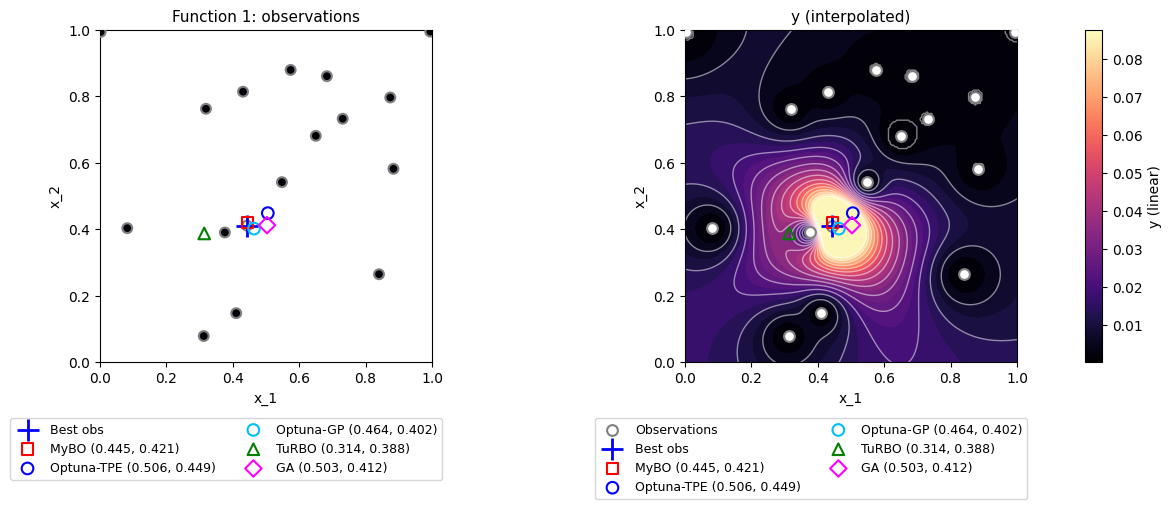

In [20]:
# MyBO = this notebook's next_x (Section 4). Optuna & TuRBO = external HPO wrappers.
bounds_01 = [(0.0, 1.0)] * 2
suggestions = [("MyBO", np.asarray(next_x).ravel())]

def _try_suggest(name, mod_path, kwargs):
    try:
        mod = __import__(mod_path, fromlist=["suggest"])
        x_pt = np.asarray(mod.suggest(X, y, **kwargs)).ravel()
        return (name, x_pt)
    except Exception as e:
        print(f"{name}: {e}")
        return None

for name, mod, kw in [
    ("Optuna-TPE", "src.optimizers.wrappers.optuna_solver", {"bounds": bounds_01, "function_id": 1, "seed": 42}),
    ("Optuna-GP",  "src.optimizers.wrappers.optuna_solver", {"bounds": bounds_01, "function_id": 1, "seed": 46, "sampler": "gp"}),
    ("TuRBO", "src.optimizers.wrappers.turbo_solver", {"bounds": bounds_01, "function_id": 1, "seed": 43}),
    ("GA", "src.optimizers.wrappers.ga_solver", {"bounds": bounds_01, "function_id": 1, "seed": 44}),
]:
    r = _try_suggest(name, mod, kw)
    if r is not None:
        suggestions.append(r)

_SOLVER_STYLE = {
    "MyBO":   ("s", "red"),
    "Optuna-TPE": ("o", "blue"),
    "Optuna-GP":  ("o", "deepskyblue"),
    "TuRBO":  ("^", "green"),
    "GA":     ("D", "magenta"),
}
_FALLBACK_STYLES = [("P", "orange"), ("*", "cyan"), ("h", "lime")]

# Section 6 summary plot: observations + solver suggestions.
dist_gx_s6 = np.sqrt(((grid_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w_s6 = 1.0 / (dist_gx_s6 ** 2)
Y_grid_s6 = ((w_s6 * y[None, :]).sum(axis=1) / w_s6.sum(axis=1)).reshape(X1g.shape)
try:
    _idw_symlog_s6 = (WARP_LABEL != "None")
except NameError:
    _idw_symlog_s6 = False
Y_grid_plot_s6, y_levels_s6, y_norm_s6 = _prepare_surface_for_plot(Y_grid_s6, force_symlog=_idw_symlog_s6)
# Norm for left panel from observation y so points span the colormap (grid norm can make them all black)
import matplotlib.colors as mcolors
_y_flat = np.asarray(y).ravel()
_y_f = _y_flat[np.isfinite(_y_flat)]
if _y_f.size > 0:
    _ymin, _ymax = float(np.min(_y_f)), float(np.max(_y_f))
    if _idw_symlog_s6 and (_ymax > 0 or _ymin < 0):
        _scale = max(abs(_ymin), abs(_ymax), 1e-30)
        _sig = _y_f[np.abs(_y_f) > _scale * 1e-8]
        _linthresh = float(np.percentile(np.abs(_sig), 10)) if len(_sig) > 0 else _scale * 1e-4
        _linthresh = max(_linthresh, 1e-30)
        y_scatter_norm = mcolors.SymLogNorm(linthresh=_linthresh, vmin=_ymin, vmax=_ymax)
    else:
        y_scatter_norm = mcolors.Normalize(vmin=_ymin, vmax=_ymax)
else:
    y_scatter_norm = y_norm_s6
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
# Left panel: observations colored by y, with best observation highlighted.
ax1.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="magma", norm=y_scatter_norm, edgecolors="gray", linewidths=1.5, zorder=5)
ax1.scatter(*best_x_so_far, s=250, marker="+", c="blue", linewidths=2, zorder=8, label="Best obs")
for idx, (name, x_pt) in enumerate(suggestions):
    mk, col = _SOLVER_STYLE.get(name, _FALLBACK_STYLES[min(idx, len(_FALLBACK_STYLES)-1)])
    if mk in ("x", "+"):
        ax1.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c=col, linewidths=2, zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
    else:
        ax1.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c="none", edgecolors=col, linewidths=1.5, zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
ax1.set_xlabel("x_1", fontsize=10); ax1.set_ylabel("x_2", fontsize=10)
ax1.set_title("Function 1: observations", fontsize=11)
ax1.set_aspect("equal"); ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.legend(loc="upper right", fontsize=9, ncol=2, bbox_to_anchor=(1.05, -0.15))
# Right: y (interpolated), same surface
cf2 = ax2.contourf(X1g, X2g, Y_grid_plot_s6, levels=y_levels_s6, norm=y_norm_s6, cmap="magma")
ax2.contour(X1g, X2g, Y_grid_plot_s6, levels=y_levels_s6[::max(1, len(y_levels_s6)//11)], colors="white", linewidths=1.0, linestyles="-", alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="gray", zorder=5, linewidths=1.5, label="Observations")
ax2.scatter(*best_x_so_far, s=250, marker="+", c="blue", linewidths=2, zorder=8, label="Best obs")
for idx, (name, x_pt) in enumerate(suggestions):
    mk, col = _SOLVER_STYLE.get(name, _FALLBACK_STYLES[min(idx, len(_FALLBACK_STYLES)-1)])
    if mk in ("x", "+"):
        ax2.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c=col, linewidths=2, zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
    else:
        ax2.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c="none", edgecolors=col, linewidths=1.5, zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
ax2.set_xlabel("x_1", fontsize=10); ax2.set_ylabel("x_2", fontsize=10)
ax2.set_title("y (interpolated)", fontsize=11)
ax2.set_aspect("equal"); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(loc="upper right", fontsize=9, ncol=2, bbox_to_anchor=(1.05, -0.15))
_scale_lbl_s6 = "SymLog scale" if hasattr(y_norm_s6, 'linthresh') else "linear"
sm_s6 = plt.cm.ScalarMappable(norm=y_norm_s6, cmap="magma")
fig2.colorbar(sm_s6, ax=[ax1, ax2], shrink=1, label=f"y ({_scale_lbl_s6})")
if IF_SHOW_PLOT:
    plt.show()
if IF_EXPORT_PLOT and PLOT_EXPORT_DIR:
    fig2.savefig(PLOT_EXPORT_DIR / "function_1_section6_summary_mean_sigma.png", dpi=150, bbox_inches="tight")
    print("Saved function_1_section6_summary_mean_sigma.png")